<a href="https://colab.research.google.com/github/np03cs4s240220-spec/2438438_Surajkiran_Shrestha_AI/blob/main/2438438_SurajkiranShrestha_L.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sarcasm Detection in News Headlines
## 6CS012 - Final Integrated Assessment: Part III - Language Task




## 1. Setup and Installation

In [ ]:
# Install required packages
!pip install numpy==1.23.5
!pip install gensim
!pip install wordcloud
!pip install gradio

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 35.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 53.9 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# IMPORTANT: Restart runtime after installs if prompted, then run this cell

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os
import time
import zipfile

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Embedding, SimpleRNN, LSTM, Dense,
                                      Dropout, Bidirectional)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score)

import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('punkt', quiet=True)
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from collections import Counter

import warnings
warnings.filterwarnings('ignore')

tf.random.set_seed(42)
np.random.seed(42)

print(f"TensorFlow: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")
print("All imports successful!")

TensorFlow: 2.20.0
GPU Available: []
All imports successful!


## 2.  Setup Save Folders, Load Dataset

In [ ]:


# ============================================================
# UPDATE THIS PATH to match YOUR Google Drive location
# ============================================================
ZIP_PATH = '/content/drive/MyDrive/6CS012_Final_Assessment/Language_Task/dataset/8. Sarcastic or Not Sarcastic Dataset-20260508T172612Z-3-001.zip'

# Setup save directories
BASE_DIR = '/content/drive/MyDrive/6CS012_Final_Assessment/Language_Task'
SAVE_DIR = f'{BASE_DIR}/figures'
os.makedirs(SAVE_DIR, exist_ok=True)
os.makedirs(f'{BASE_DIR}/notebook', exist_ok=True)
os.makedirs(f'{BASE_DIR}/outputs', exist_ok=True)

def save_plot(name):
    plt.savefig(f'{SAVE_DIR}/{name}.png', dpi=150, bbox_inches='tight')
    print(f"Saved: {SAVE_DIR}/{name}.png")

# Unzip dataset
EXTRACT_DIR = '/content/sarcasm_data'
os.makedirs(EXTRACT_DIR, exist_ok=True)

print("Extracting dataset...")
with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
    zip_ref.extractall(EXTRACT_DIR)

# Find CSV automatically
csv_path = None
for root, dirs, files in os.walk(EXTRACT_DIR):
    for f in files:
        if f.endswith('.csv'):
            csv_path = os.path.join(root, f)
            break

print(f"Found CSV at: {csv_path}")

# Load dataset
df = pd.read_csv(csv_path)
print(f"Dataset loaded! Shape: {df.shape}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Extracting dataset...
Found CSV at: /content/sarcasm_data/8. Sarcastic or Not Sarcastic Dataset/sarcastic_headlines.csv
Dataset loaded! Shape: (28619, 2)


## 3. Data Exploration

In [ ]:
# Dataset overview
print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nClass Distribution:")
print(df['is_sarcastic'].value_counts())
print(f"\nClass Proportions:")
print(df['is_sarcastic'].value_counts(normalize=True))

print("\nFirst 5 rows:")
df.head()

DATASET OVERVIEW
Shape: (28619, 2)
Columns: ['headline', 'is_sarcastic']

Missing values:
headline        0
is_sarcastic    0
dtype: int64

Class Distribution:
is_sarcastic
0    14985
1    13634
Name: count, dtype: int64

Class Proportions:
is_sarcastic
0    0.523603
1    0.476397
Name: proportion, dtype: float64

First 5 rows:


,headline,is_sarcastic
0,thirtysomething scientists unveil doomsday clo...,1
1,dem rep. totally nails why congress is falling...,0
2,eat your veggies: 9 deliciously different recipes,0
3,inclement weather prevents liar from getting t...,1
4,mother comes pretty close to using word 'strea...,1


Saved: /content/drive/MyDrive/6CS012_Final_Assessment/Language_Task/figures/class_distribution.png


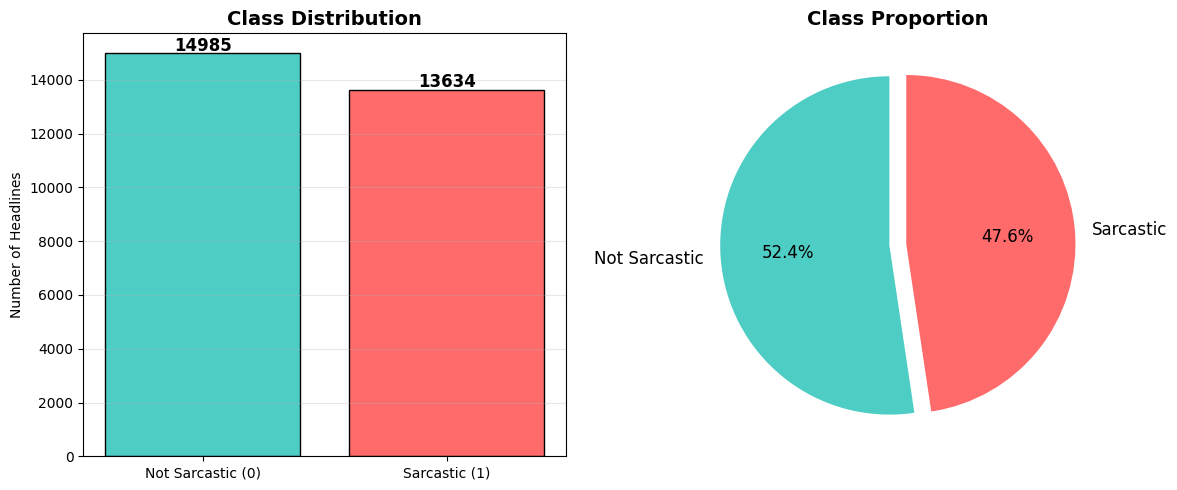


Sample Headlines:

Sarcastic examples:
  -> thirtysomething scientists unveil doomsday clock of hair loss
  -> inclement weather prevents liar from getting to work
  -> mother comes pretty close to using word 'streaming' correctly

Not Sarcastic examples:
  -> dem rep. totally nails why congress is falling short on gender, racial equality
  -> eat your veggies: 9 deliciously different recipes
  -> my white inheritance


In [ ]:
# Class distribution visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

colors = ['#4ECDC4', '#FF6B6B']
counts = df['is_sarcastic'].value_counts()

bars = ax1.bar(['Not Sarcastic (0)', 'Sarcastic (1)'], counts.values, color=colors, edgecolor='black')
for bar, count in zip(bars, counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 100,
             str(count), ha='center', fontweight='bold', fontsize=12)
ax1.set_title('Class Distribution', fontsize=14, fontweight='bold')
ax1.set_ylabel('Number of Headlines')
ax1.grid(axis='y', alpha=0.3)

ax2.pie(counts.values, labels=['Not Sarcastic', 'Sarcastic'],
        colors=colors, autopct='%1.1f%%', startangle=90,
        textprops={'fontsize': 12}, explode=(0.05, 0.05))
ax2.set_title('Class Proportion', fontsize=14, fontweight='bold')

plt.tight_layout()
save_plot('class_distribution')
plt.show()

print("\nSample Headlines:")
print("\nSarcastic examples:")
for h in df[df['is_sarcastic']==1]['headline'].head(3).values:
    print(f"  -> {h}")
print("\nNot Sarcastic examples:")
for h in df[df['is_sarcastic']==0]['headline'].head(3).values:
    print(f"  -> {h}")

### 3.1 Text Length Analysis

Saved: /content/drive/MyDrive/6CS012_Final_Assessment/Language_Task/figures/text_length_analysis.png


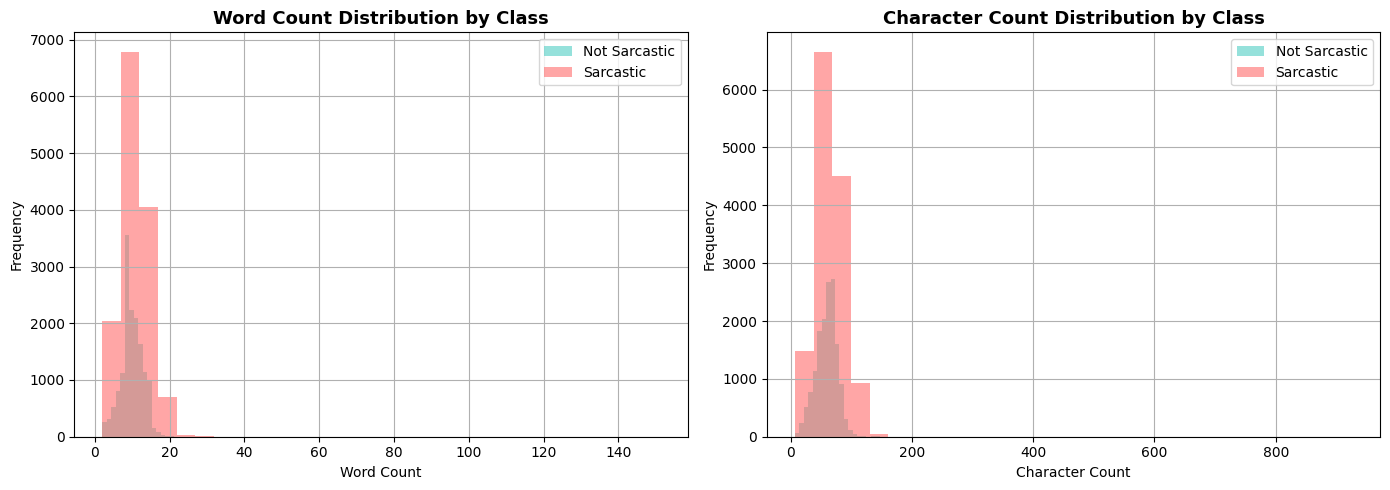


Word Count Stats:
                count       mean       std  min  25%   50%   75%    max
is_sarcastic                                                           
0             14985.0   9.815616  2.886045  2.0  8.0  10.0  12.0   38.0
1             13634.0  10.307540  3.849470  2.0  8.0  10.0  13.0  151.0


In [ ]:
# Text length analysis
df['word_count'] = df['headline'].apply(lambda x: len(str(x).split()))
df['char_count'] = df['headline'].apply(lambda x: len(str(x)))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

df[df['is_sarcastic']==0]['word_count'].hist(ax=ax1, bins=30, alpha=0.6, color='#4ECDC4', label='Not Sarcastic')
df[df['is_sarcastic']==1]['word_count'].hist(ax=ax1, bins=30, alpha=0.6, color='#FF6B6B', label='Sarcastic')
ax1.set_title('Word Count Distribution by Class', fontsize=13, fontweight='bold')
ax1.set_xlabel('Word Count')
ax1.set_ylabel('Frequency')
ax1.legend()

df[df['is_sarcastic']==0]['char_count'].hist(ax=ax2, bins=30, alpha=0.6, color='#4ECDC4', label='Not Sarcastic')
df[df['is_sarcastic']==1]['char_count'].hist(ax=ax2, bins=30, alpha=0.6, color='#FF6B6B', label='Sarcastic')
ax2.set_title('Character Count Distribution by Class', fontsize=13, fontweight='bold')
ax2.set_xlabel('Character Count')
ax2.set_ylabel('Frequency')
ax2.legend()

plt.tight_layout()
save_plot('text_length_analysis')
plt.show()

print(f"\nWord Count Stats:")
print(df.groupby('is_sarcastic')['word_count'].describe())

---
## 4. Text Preprocessing, Tokenization, and Sequence Padding

### 4.1 Text Cleaning


In [ ]:
# Contractions dictionary
contractions = {
    "don't": "do not", "can't": "cannot", "won't": "will not",
    "isn't": "is not", "aren't": "are not", "wasn't": "was not",
    "weren't": "were not", "hasn't": "has not", "haven't": "have not",
    "hadn't": "had not", "didn't": "did not", "doesn't": "does not",
    "couldn't": "could not", "shouldn't": "should not", "wouldn't": "would not",
    "mustn't": "must not", "needn't": "need not",
    "i'm": "i am", "you're": "you are", "he's": "he is",
    "she's": "she is", "it's": "it is", "we're": "we are",
    "they're": "they are", "i've": "i have", "you've": "you have",
    "we've": "we have", "they've": "they have",
    "i'll": "i will", "you'll": "you will", "he'll": "he will",
    "she'll": "she will", "it'll": "it will", "we'll": "we will",
    "they'll": "they will", "i'd": "i would", "you'd": "you would",
    "he'd": "he would", "she'd": "she would", "we'd": "we would",
    "they'd": "they would", "that's": "that is", "who's": "who is",
    "what's": "what is", "here's": "here is", "there's": "there is",
    "where's": "where is", "how's": "how is", "let's": "let us",
}

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#\w+', '', text)
    for contraction, expansion in contractions.items():
        text = text.replace(contraction, expansion)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    words = text.split()
    words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words and len(w) > 2]
    return ' '.join(words)

print("Cleaning text data...")
df['cleaned_text'] = df['headline'].apply(clean_text)

print("\nSample Cleaning Results:")
print("=" * 80)
for i in range(5):
    print(f"\nOriginal:  {df['headline'].iloc[i]}")
    print(f"Cleaned:   {df['cleaned_text'].iloc[i]}")
    print("-" * 80)

df = df[df['cleaned_text'].str.strip().astype(bool)]
print(f"\nDataset size after cleaning: {len(df)}")

Cleaning text data...

Sample Cleaning Results:

Original:  thirtysomething scientists unveil doomsday clock of hair loss
Cleaned:   thirtysomething scientist unveil doomsday clock hair loss
--------------------------------------------------------------------------------

Original:  dem rep. totally nails why congress is falling short on gender, racial equality
Cleaned:   dem rep totally nail congress falling short gender racial equality
--------------------------------------------------------------------------------

Original:  eat your veggies: 9 deliciously different recipes
Cleaned:   eat veggie deliciously different recipe
--------------------------------------------------------------------------------

Original:  inclement weather prevents liar from getting to work
Cleaned:   inclement weather prevents liar getting work
--------------------------------------------------------------------------------

Original:  mother comes pretty close to using word 'streaming' correctly
Cleaned

### 4.2 Visualize Cleaned Data

Saved: /content/drive/MyDrive/6CS012_Final_Assessment/Language_Task/figures/word_clouds.png


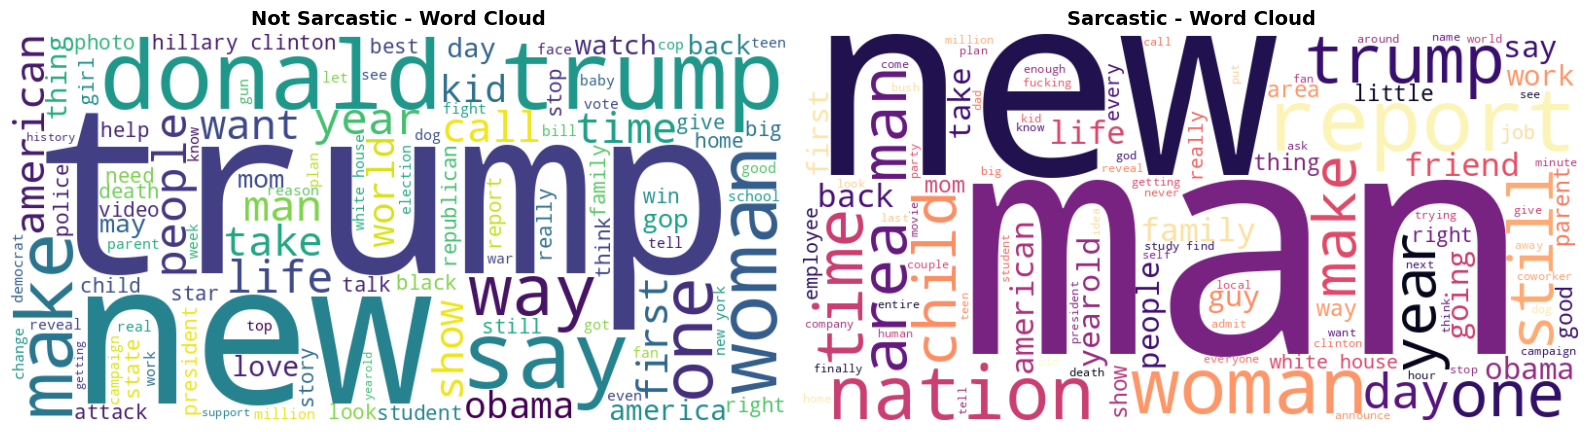

In [ ]:
from wordcloud import WordCloud

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

text_not_sarc = ' '.join(df[df['is_sarcastic']==0]['cleaned_text'])
wc1 = WordCloud(width=800, height=400, background_color='white',
                colormap='viridis', max_words=100).generate(text_not_sarc)
ax1.imshow(wc1, interpolation='bilinear')
ax1.set_title('Not Sarcastic - Word Cloud', fontsize=14, fontweight='bold')
ax1.axis('off')

text_sarc = ' '.join(df[df['is_sarcastic']==1]['cleaned_text'])
wc2 = WordCloud(width=800, height=400, background_color='white',
                colormap='magma', max_words=100).generate(text_sarc)
ax2.imshow(wc2, interpolation='bilinear')
ax2.set_title('Sarcastic - Word Cloud', fontsize=14, fontweight='bold')
ax2.axis('off')

plt.tight_layout()
save_plot('word_clouds')
plt.show()

Saved: /content/drive/MyDrive/6CS012_Final_Assessment/Language_Task/figures/top_20_words.png


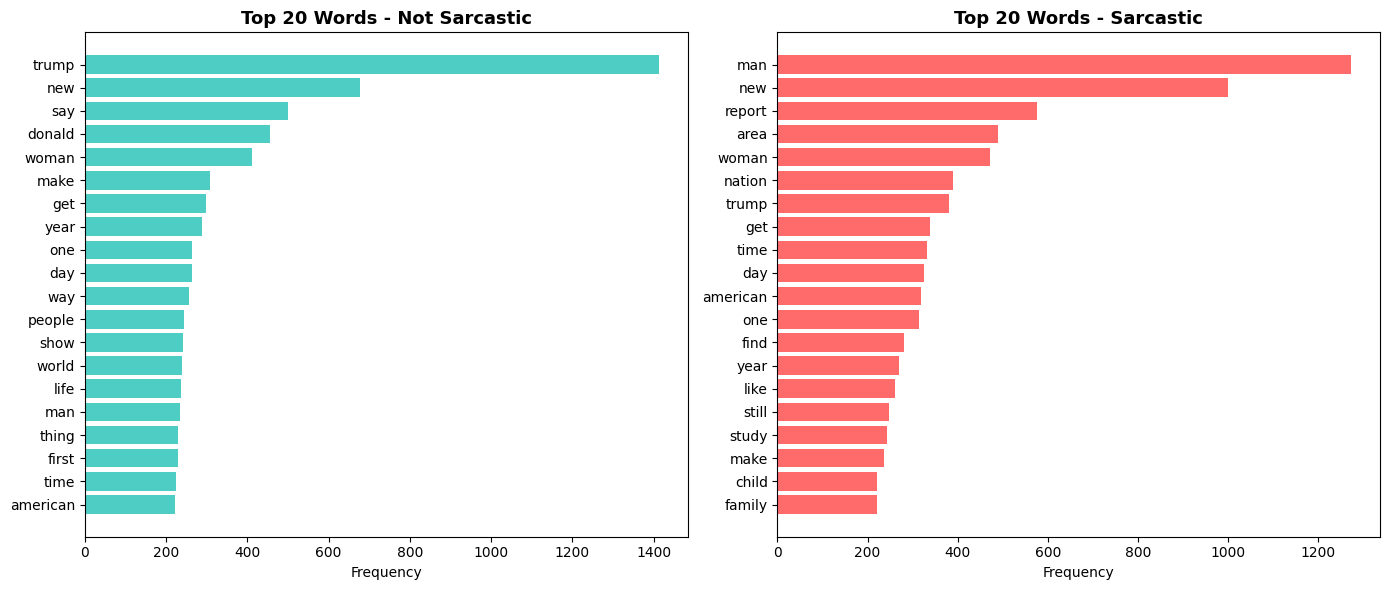

In [ ]:
# Top 20 most frequent words per class
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

words_ns = Counter(' '.join(df[df['is_sarcastic']==0]['cleaned_text']).split())
common_ns = words_ns.most_common(20)
words_n, counts_n = zip(*common_ns)
ax1.barh(range(len(words_n)), counts_n, color='#4ECDC4')
ax1.set_yticks(range(len(words_n)))
ax1.set_yticklabels(words_n)
ax1.invert_yaxis()
ax1.set_title('Top 20 Words - Not Sarcastic', fontsize=13, fontweight='bold')
ax1.set_xlabel('Frequency')

words_s = Counter(' '.join(df[df['is_sarcastic']==1]['cleaned_text']).split())
common_s = words_s.most_common(20)
words_sa, counts_sa = zip(*common_s)
ax2.barh(range(len(words_sa)), counts_sa, color='#FF6B6B')
ax2.set_yticks(range(len(words_sa)))
ax2.set_yticklabels(words_sa)
ax2.invert_yaxis()
ax2.set_title('Top 20 Words - Sarcastic', fontsize=13, fontweight='bold')
ax2.set_xlabel('Frequency')

plt.tight_layout()
save_plot('top_20_words')
plt.show()

### 4.3 Tokenization and Padding

In [ ]:
# Split data: 80% train, 20% test
X = df['cleaned_text']
y = df['is_sarcastic'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {len(X_train)} samples")
print(f"Test set:     {len(X_test)} samples")
print(f"\nTrain class distribution: {Counter(y_train)}")
print(f"Test class distribution:  {Counter(y_test)}")

Training set: 22892 samples
Test set:     5724 samples

Train class distribution: Counter({np.int64(0): 11985, np.int64(1): 10907})
Test class distribution:  Counter({np.int64(0): 2997, np.int64(1): 2727})


Vocabulary Size: 22375

Sequence Length Statistics:
  Min: 1
  Max: 106
  Mean: 7.0
  Median: 7.0
  95th Percentile: 11

Chosen MAX_LENGTH (95th percentile): 11
Saved: /content/drive/MyDrive/6CS012_Final_Assessment/Language_Task/figures/sequence_length_distribution.png


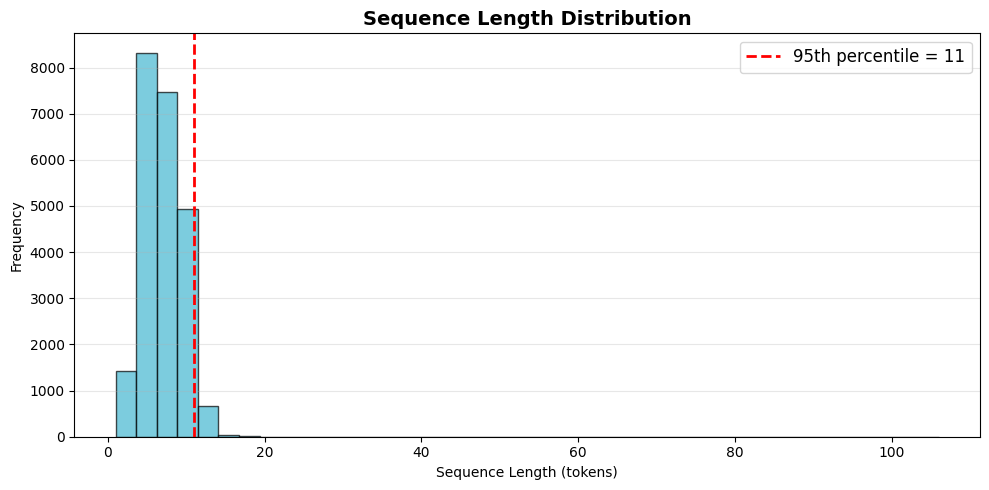

In [ ]:
# Tokenization
tokenizer = Tokenizer(oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

vocab_size = len(tokenizer.word_index) + 1
print(f"Vocabulary Size: {vocab_size}")

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

seq_lengths = [len(seq) for seq in X_train_seq]
print(f"\nSequence Length Statistics:")
print(f"  Min: {min(seq_lengths)}")
print(f"  Max: {max(seq_lengths)}")
print(f"  Mean: {np.mean(seq_lengths):.1f}")
print(f"  Median: {np.median(seq_lengths):.1f}")
print(f"  95th Percentile: {np.percentile(seq_lengths, 95):.0f}")

MAX_LENGTH = int(np.percentile(seq_lengths, 95))
print(f"\nChosen MAX_LENGTH (95th percentile): {MAX_LENGTH}")

plt.figure(figsize=(10, 5))
plt.hist(seq_lengths, bins=40, color='#45B7D1', edgecolor='black', alpha=0.7)
plt.axvline(x=MAX_LENGTH, color='red', linestyle='--', linewidth=2, label=f'95th percentile = {MAX_LENGTH}')
plt.title('Sequence Length Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Sequence Length (tokens)')
plt.ylabel('Frequency')
plt.legend(fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
save_plot('sequence_length_distribution')
plt.show()

In [ ]:
# Apply padding
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LENGTH, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LENGTH, padding='post', truncating='post')

print(f"Padded training shape: {X_train_pad.shape}")
print(f"Padded test shape:     {X_test_pad.shape}")
print(f"\nSample padded sequence (first 20 tokens): {X_train_pad[0][:20]}")

Padded training shape: (22892, 11)
Padded test shape:     (5724, 11)

Sample padded sequence (first 20 tokens): [1365  101  599   38  323  831 3689    0    0    0    0]


---
## 5. Model Building and Training

### 5.1 Model 1: Simple RNN with Trainable Embedding


In [ ]:
# Model 1: Simple RNN
EMBEDDING_DIM = 64

model_rnn = Sequential([
    Embedding(input_dim=vocab_size, output_dim=EMBEDDING_DIM, input_length=MAX_LENGTH),
    SimpleRNN(64, return_sequences=False),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

model_rnn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("=" * 60)
print("MODEL 1: Simple RNN")
print("=" * 60)
model_rnn.summary()

MODEL 1: Simple RNN


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train Model 1
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

print("Training Model 1: Simple RNN...")
start_time = time.time()

history_rnn = model_rnn.fit(
    X_train_pad, y_train, epochs=20, batch_size=64,
    validation_split=0.2, callbacks=[early_stop], verbose=1
)

rnn_time = time.time() - start_time
print(f"\nRNN Training Time: {rnn_time:.1f} seconds")

Training Model 1: Simple RNN...
Epoch 1/20
287/287 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - accuracy: 0.7382 - loss: 0.5172 - val_accuracy: 0.7855 - val_loss: 0.4465
Epoch 2/20
287/287 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.9184 - loss: 0.2110 - val_accuracy: 0.7869 - val_loss: 0.6041
Epoch 3/20
287/287 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.9789 - loss: 0.0653 - val_accuracy: 0.7713 - val_loss: 0.9152
Epoch 4/20
287/287 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.9897 - loss: 0.0332 - val_accuracy: 0.7574 - val_loss: 0.9931

RNN Training Time: 27.4 seconds


### 5.2 Model 2: LSTM with Trainable Embedding

In [ ]:
# Model 2: LSTM
model_lstm = Sequential([
    Embedding(input_dim=vocab_size, output_dim=EMBEDDING_DIM, input_length=MAX_LENGTH),
    LSTM(64, return_sequences=False),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

model_lstm.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("=" * 60)
print("MODEL 2: LSTM")
print("=" * 60)
model_lstm.summary()

MODEL 2: LSTM


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train Model 2
print("Training Model 2: LSTM...")
start_time = time.time()

history_lstm = model_lstm.fit(
    X_train_pad, y_train, epochs=20, batch_size=64,
    validation_split=0.2, callbacks=[early_stop], verbose=1
)

lstm_time = time.time() - start_time
print(f"\nLSTM Training Time: {lstm_time:.1f} seconds")

Training Model 2: LSTM...
Epoch 1/20
287/287 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - accuracy: 0.7306 - loss: 0.5188 - val_accuracy: 0.7930 - val_loss: 0.4405
Epoch 2/20
287/287 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.8887 - loss: 0.2718 - val_accuracy: 0.7834 - val_loss: 0.5305
Epoch 3/20
287/287 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.9511 - loss: 0.1380 - val_accuracy: 0.7650 - val_loss: 0.7555
Epoch 4/20
287/287 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - accuracy: 0.9695 - loss: 0.0934 - val_accuracy: 0.7497 - val_loss: 0.8788

LSTM Training Time: 28.1 seconds


### 5.3 Model 3: LSTM with Pre-trained Word2Vec (GloVe) Embeddings

In [ ]:
# Load pre-trained GloVe embeddings
import gensim.downloader as api

print("Loading pre-trained GloVe embeddings (this may take a few minutes)...")
W2V_EMBEDDING_DIM = 100
embedding_model = api.load('glove-wiki-gigaword-100')
print(f"Loaded! Vocabulary size: {len(embedding_model)}")

Loading pre-trained GloVe embeddings (this may take a few minutes)...
[==================================================] 100.0% 128.1/128.1MB downloaded
Loaded! Vocabulary size: 400000


In [ ]:
# Build embedding matrix
word_index = tokenizer.word_index
embedding_matrix = np.zeros((vocab_size, W2V_EMBEDDING_DIM))

found_count = 0
not_found_count = 0

for word, i in word_index.items():
    if word in embedding_model:
        embedding_matrix[i] = embedding_model[word]
        found_count += 1
    else:
        not_found_count += 1

print(f"Words found in GloVe: {found_count} ({found_count/len(word_index)*100:.1f}%)")
print(f"Words NOT found: {not_found_count} ({not_found_count/len(word_index)*100:.1f}%)")
print(f"Embedding matrix shape: {embedding_matrix.shape}")

Words found in GloVe: 19574 (87.5%)
Words NOT found: 2800 (12.5%)
Embedding matrix shape: (22375, 100)


In [ ]:
# Model 3: LSTM with pre-trained Word2Vec
model_w2v = Sequential([
    Embedding(input_dim=vocab_size, output_dim=W2V_EMBEDDING_DIM,
              weights=[embedding_matrix], input_length=MAX_LENGTH,
              trainable=False),
    LSTM(64, return_sequences=False),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

model_w2v.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("=" * 60)
print("MODEL 3: LSTM + Word2Vec (GloVe)")
print("=" * 60)
model_w2v.summary()

MODEL 3: LSTM + Word2Vec (GloVe)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │     2,237,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,237,500 (8.54 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,237,500 (8.54 MB)

In [ ]:
# Train Model 3
print("Training Model 3: LSTM + Word2Vec...")
start_time = time.time()

history_w2v = model_w2v.fit(
    X_train_pad, y_train, epochs=20, batch_size=64,
    validation_split=0.2, callbacks=[early_stop], verbose=1
)

w2v_time = time.time() - start_time
print(f"\nLSTM + Word2Vec Training Time: {w2v_time:.1f} seconds")

Training Model 3: LSTM + Word2Vec...
Epoch 1/20
287/287 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.6933 - loss: 0.5784 - val_accuracy: 0.7268 - val_loss: 0.5343
Epoch 2/20
287/287 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.7666 - loss: 0.4856 - val_accuracy: 0.7593 - val_loss: 0.4935
Epoch 3/20
287/287 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.7981 - loss: 0.4359 - val_accuracy: 0.7744 - val_loss: 0.4671

LSTM + Word2Vec Training Time: 14.8 seconds


---
## 6. Model Evaluation and Comparison

### 6.1 Training Curves - All Models


Saved: /content/drive/MyDrive/6CS012_Final_Assessment/Language_Task/figures/all_models_training_curves.png


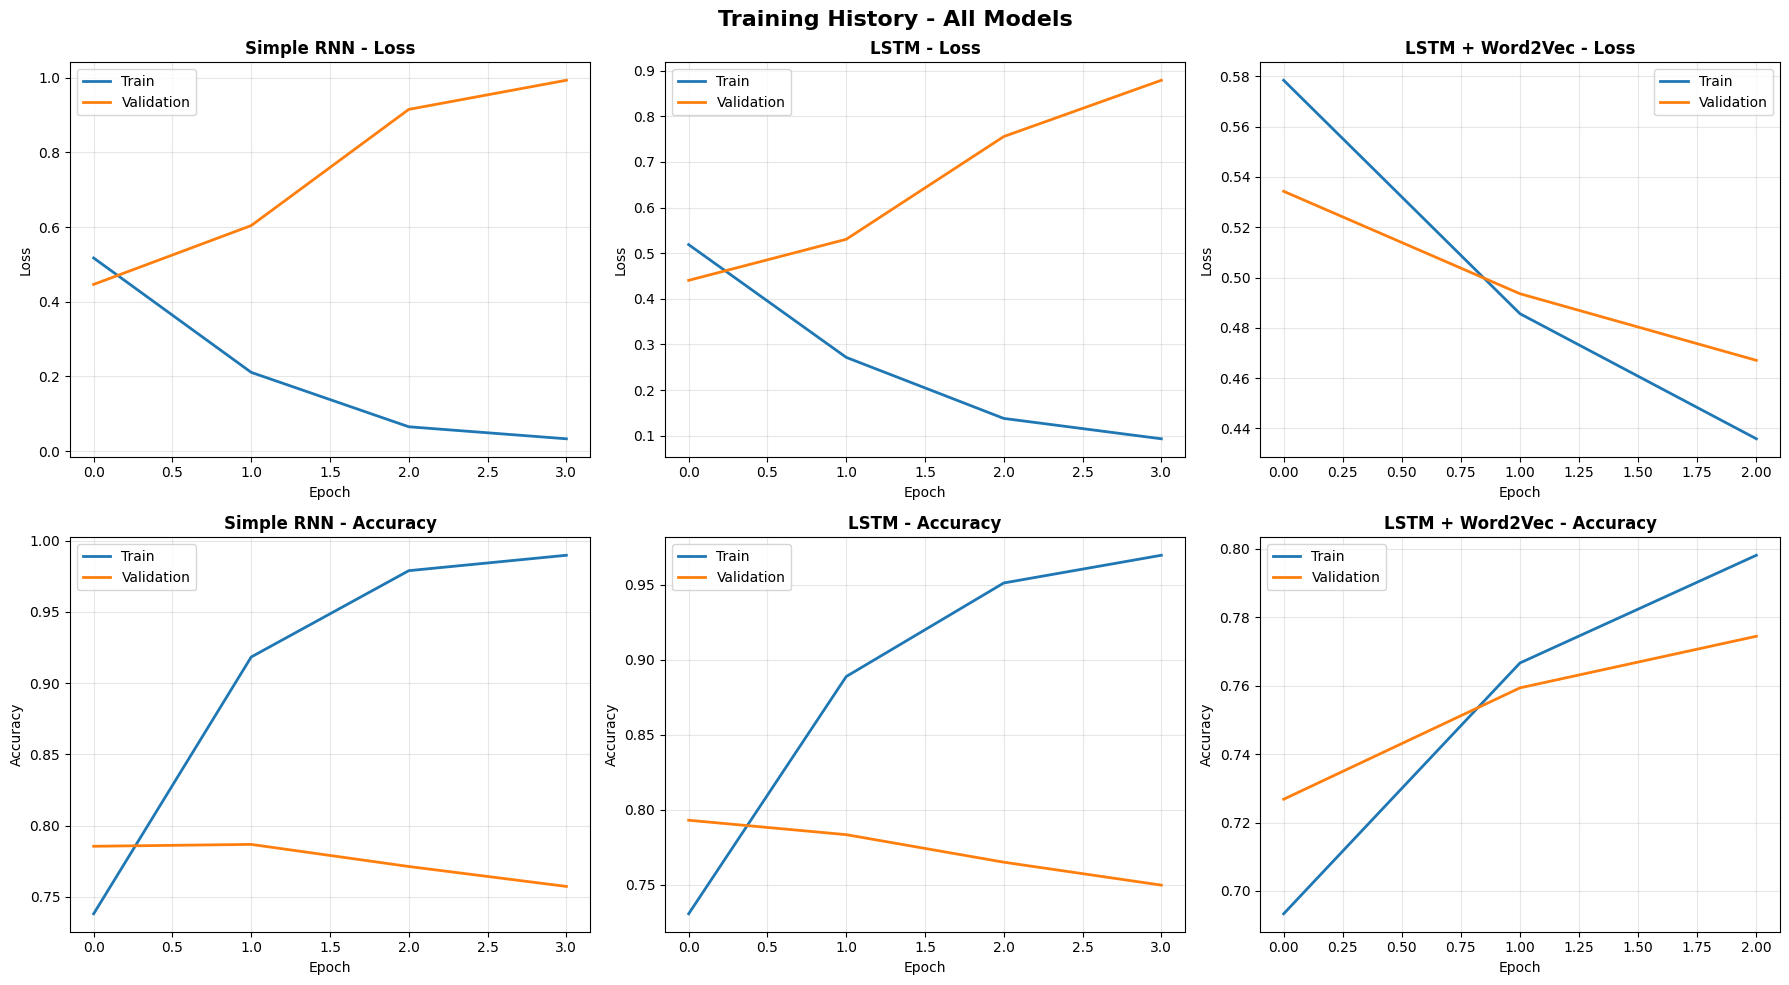

In [ ]:
# Training curves for all three models
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Training History - All Models', fontsize=16, fontweight='bold')

models_info = [
    ('Simple RNN', history_rnn),
    ('LSTM', history_lstm),
    ('LSTM + Word2Vec', history_w2v)
]

for idx, (name, history) in enumerate(models_info):
    axes[0, idx].plot(history.history['loss'], label='Train', linewidth=2)
    axes[0, idx].plot(history.history['val_loss'], label='Validation', linewidth=2)
    axes[0, idx].set_title(f'{name} - Loss', fontsize=12, fontweight='bold')
    axes[0, idx].set_xlabel('Epoch')
    axes[0, idx].set_ylabel('Loss')
    axes[0, idx].legend()
    axes[0, idx].grid(True, alpha=0.3)

    axes[1, idx].plot(history.history['accuracy'], label='Train', linewidth=2)
    axes[1, idx].plot(history.history['val_accuracy'], label='Validation', linewidth=2)
    axes[1, idx].set_title(f'{name} - Accuracy', fontsize=12, fontweight='bold')
    axes[1, idx].set_xlabel('Epoch')
    axes[1, idx].set_ylabel('Accuracy')
    axes[1, idx].legend()
    axes[1, idx].grid(True, alpha=0.3)

plt.tight_layout()
save_plot('all_models_training_curves')
plt.show()

### 6.2 Model Comparison (Overlay)

Saved: /content/drive/MyDrive/6CS012_Final_Assessment/Language_Task/figures/model_comparison_overlay.png


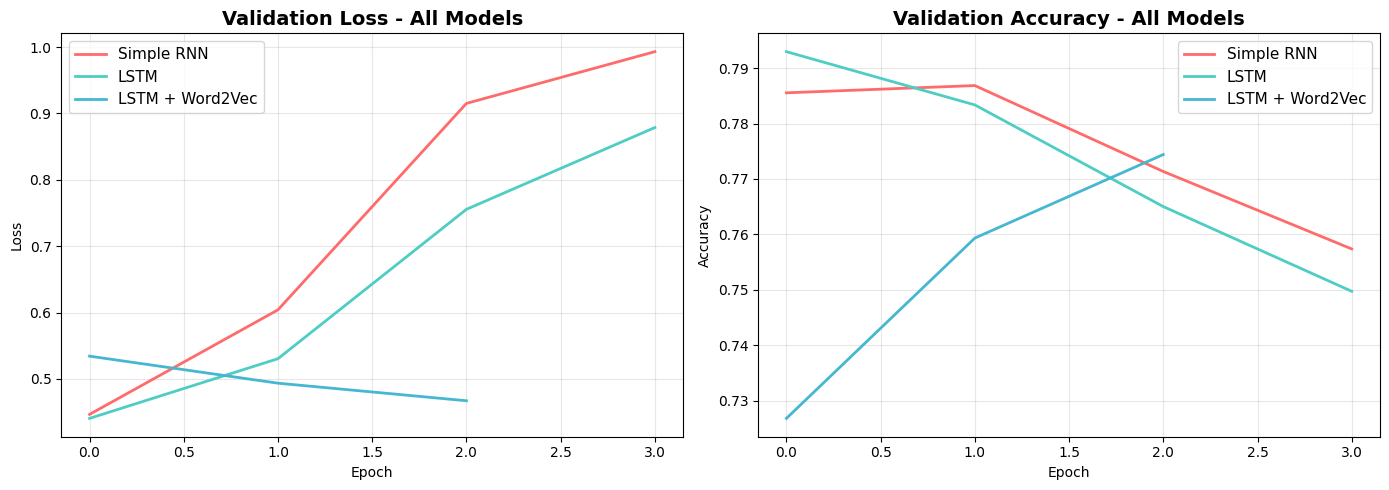

In [ ]:
# Overlay comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

for (name, history), color in zip(models_info, colors):
    ax1.plot(history.history['val_loss'], label=name, linewidth=2, color=color)
    ax2.plot(history.history['val_accuracy'], label=name, linewidth=2, color=color)

ax1.set_title('Validation Loss - All Models', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

ax2.set_title('Validation Accuracy - All Models', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
save_plot('model_comparison_overlay')
plt.show()

### 6.3 Model Evaluation on Test Set

In [ ]:
# Evaluate all models on test set
print("=" * 70)
print("MODEL EVALUATION ON TEST SET")
print("=" * 70)

results = {}

for name, model in [('Simple RNN', model_rnn), ('LSTM', model_lstm), ('LSTM + Word2Vec', model_w2v)]:
    y_pred_prob = model.predict(X_test_pad, verbose=0)
    y_pred = (y_pred_prob > 0.5).astype(int).flatten()

    acc = accuracy_score(y_test, y_pred)
    results[name] = {
        'accuracy': acc,
        'predictions': y_pred,
        'probabilities': y_pred_prob
    }

    print(f"\n{'='*60}")
    print(f"{name}")
    print(f"{'='*60}")
    print(f"Test Accuracy: {acc:.4f} ({acc*100:.2f}%)")
    print(f"\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['Not Sarcastic', 'Sarcastic']))

MODEL EVALUATION ON TEST SET

Simple RNN
Test Accuracy: 0.7966 (79.66%)

Classification Report:
               precision    recall  f1-score   support

Not Sarcastic       0.77      0.87      0.82      2997
    Sarcastic       0.83      0.72      0.77      2727

     accuracy                           0.80      5724
    macro avg       0.80      0.79      0.79      5724
 weighted avg       0.80      0.80      0.80      5724


LSTM
Test Accuracy: 0.7905 (79.05%)

Classification Report:
               precision    recall  f1-score   support

Not Sarcastic       0.78      0.83      0.81      2997
    Sarcastic       0.80      0.75      0.77      2727

     accuracy                           0.79      5724
    macro avg       0.79      0.79      0.79      5724
 weighted avg       0.79      0.79      0.79      5724


LSTM + Word2Vec
Test Accuracy: 0.7411 (74.11%)

Classification Report:
               precision    recall  f1-score   support

Not Sarcastic       0.71      0.86      0.78     

### 6.4 Confusion Matrices

Saved: /content/drive/MyDrive/6CS012_Final_Assessment/Language_Task/figures/confusion_matrices.png


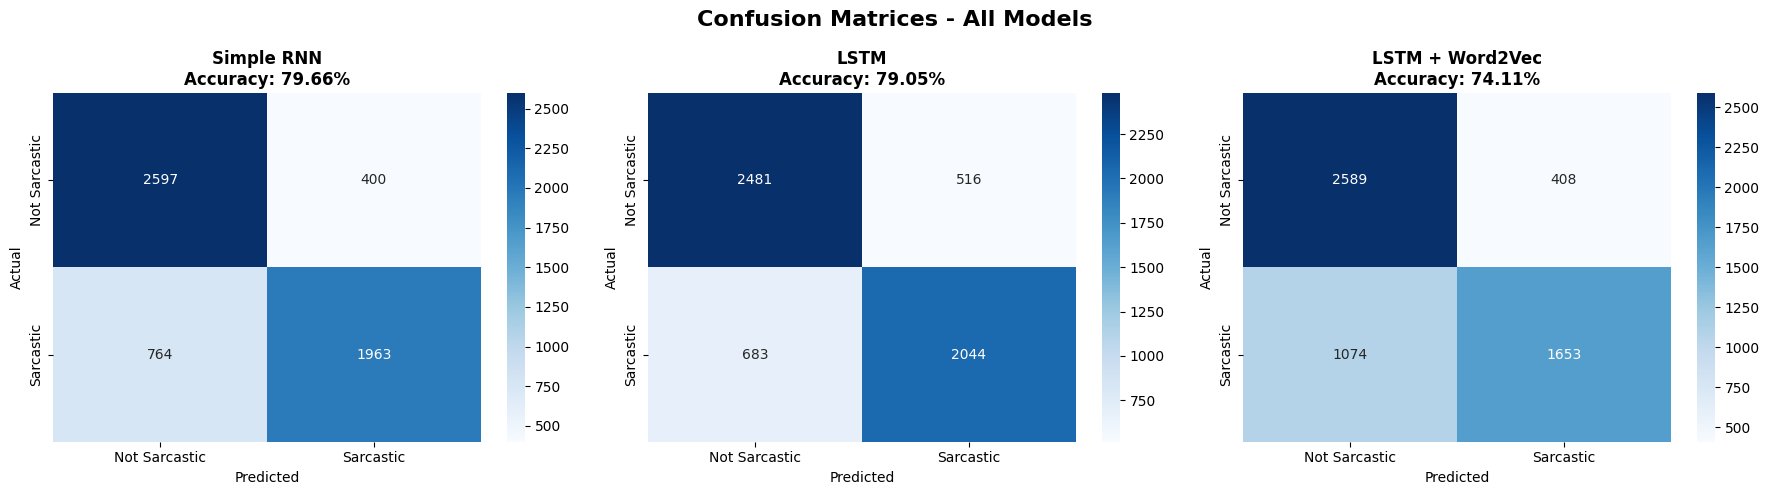

In [ ]:
# Confusion matrices for all models
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Confusion Matrices - All Models', fontsize=16, fontweight='bold')

for idx, (name, data) in enumerate(results.items()):
    cm = confusion_matrix(y_test, data['predictions'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['Not Sarcastic', 'Sarcastic'],
                yticklabels=['Not Sarcastic', 'Sarcastic'])
    axes[idx].set_title(f'{name}\nAccuracy: {data["accuracy"]:.2%}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')

plt.tight_layout()
save_plot('confusion_matrices')
plt.show()

### 6.5 Results Summary

COMPREHENSIVE RESULTS SUMMARY
Model                       Test Accuracy   Training Time
----------------------------------------------------------------------
Simple RNN                         0.7966          27.4s
LSTM                               0.7905          28.1s
LSTM + Word2Vec                    0.7411          14.8s
----------------------------------------------------------------------
Saved: /content/drive/MyDrive/6CS012_Final_Assessment/Language_Task/figures/model_accuracy_comparison.png


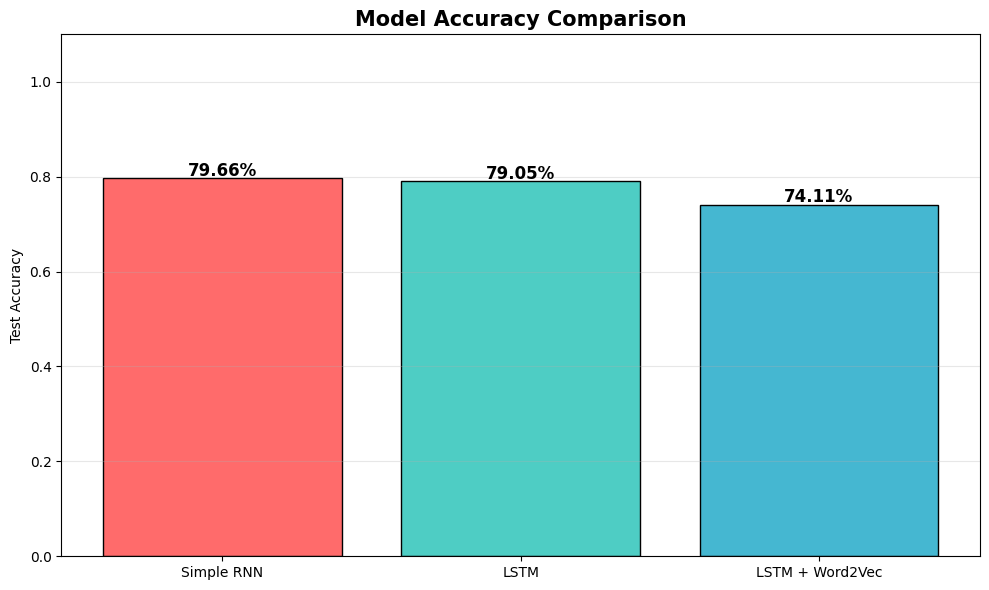


Best Performing Model: Simple RNN (79.66%)


In [ ]:
# Final comparison
print("=" * 70)
print("COMPREHENSIVE RESULTS SUMMARY")
print("=" * 70)
print(f"{'Model':<25} {'Test Accuracy':>15} {'Training Time':>15}")
print("-" * 70)
print(f"{'Simple RNN':<25} {results['Simple RNN']['accuracy']:>15.4f} {rnn_time:>13.1f}s")
print(f"{'LSTM':<25} {results['LSTM']['accuracy']:>15.4f} {lstm_time:>13.1f}s")
print(f"{'LSTM + Word2Vec':<25} {results['LSTM + Word2Vec']['accuracy']:>15.4f} {w2v_time:>13.1f}s")
print("-" * 70)

# Bar chart comparison
plt.figure(figsize=(10, 6))
model_names = list(results.keys())
accuracies = [results[m]['accuracy'] for m in model_names]
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

bars = plt.bar(model_names, accuracies, color=colors, edgecolor='black')
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
             f'{acc:.2%}', ha='center', fontweight='bold', fontsize=12)

plt.title('Model Accuracy Comparison', fontsize=15, fontweight='bold')
plt.ylabel('Test Accuracy')
plt.ylim(0, 1.1)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
save_plot('model_accuracy_comparison')
plt.show()

best_model_name = max(results, key=lambda x: results[x]['accuracy'])
print(f"\nBest Performing Model: {best_model_name} ({results[best_model_name]['accuracy']:.2%})")

---
## 7. Error Analysis

In [ ]:
# Error Analysis
best_model = model_lstm
best_model_name_ea = 'LSTM'

y_pred_prob_ea = best_model.predict(X_test_pad, verbose=0).flatten()
y_pred_ea = (y_pred_prob_ea > 0.5).astype(int)

X_test_texts = X_test.values
misclassified_mask = y_pred_ea != y_test
misclassified_indices = np.where(misclassified_mask)[0]

print("=" * 70)
print(f"ERROR ANALYSIS ({best_model_name_ea} Model)")
print("=" * 70)
print(f"Total test samples: {len(y_test)}")
print(f"Correct predictions: {np.sum(~misclassified_mask)}")
print(f"Misclassified: {np.sum(misclassified_mask)} ({np.mean(misclassified_mask)*100:.1f}%)")

print("\n" + "=" * 70)
print("SAMPLE MISCLASSIFIED HEADLINES")
print("=" * 70)

for i, idx in enumerate(misclassified_indices[:5]):
    true_label = "Sarcastic" if y_test[idx] == 1 else "Not Sarcastic"
    pred_label = "Sarcastic" if y_pred_ea[idx] == 1 else "Not Sarcastic"
    confidence = y_pred_prob_ea[idx] if y_pred_ea[idx] == 1 else 1 - y_pred_prob_ea[idx]

    print(f"\nExample {i+1}:")
    print(f"  Headline:   {X_test_texts[idx]}")
    print(f"  True Label: {true_label}")
    print(f"  Predicted:  {pred_label} (confidence: {confidence:.2%})")
    print(f"  Raw Score:  {y_pred_prob_ea[idx]:.4f}")
    print("-" * 70)

ERROR ANALYSIS (LSTM Model)
Total test samples: 5724
Correct predictions: 4525
Misclassified: 1199 (20.9%)

SAMPLE MISCLASSIFIED HEADLINES

Example 1:
  Headline:   lady gaga rock god cover new single perfect illusion
  True Label: Not Sarcastic
  Predicted:  Sarcastic (confidence: 69.20%)
  Raw Score:  0.6920
----------------------------------------------------------------------

Example 2:
  Headline:   detroitarea resident demand clean air
  True Label: Not Sarcastic
  Predicted:  Sarcastic (confidence: 82.86%)
  Raw Score:  0.8286
----------------------------------------------------------------------

Example 3:
  Headline:   line cook learns leaving restaurant industry easy
  True Label: Sarcastic
  Predicted:  Not Sarcastic (confidence: 65.66%)
  Raw Score:  0.3434
----------------------------------------------------------------------

Example 4:
  Headline:   world bank accidentally left voicemail discussing strategy downplay right abuse
  True Label: Not Sarcastic
  Predicted: 

In [ ]:
# Error type breakdown
false_positives = np.sum((y_pred_ea == 1) & (y_test == 0))
false_negatives = np.sum((y_pred_ea == 0) & (y_test == 1))
true_positives = np.sum((y_pred_ea == 1) & (y_test == 1))
true_negatives = np.sum((y_pred_ea == 0) & (y_test == 0))

print("Error Type Breakdown:")
print(f"  True Positives (correctly identified sarcasm):  {true_positives}")
print(f"  True Negatives (correctly identified non-sarc): {true_negatives}")
print(f"  False Positives (incorrectly flagged as sarc):  {false_positives}")
print(f"  False Negatives (missed sarcasm):               {false_negatives}")

print("\nPossible Reasons for Misclassification:")
print("  1. Sarcasm relies on context, tone, and cultural knowledge")
print("  2. Some headlines are ambiguous - even humans may disagree")
print("  3. Short headlines provide limited context for the model")
print("  4. Words not in training vocabulary (OOV tokens) lose meaning")
print("  5. Subtle sarcasm without explicit markers is harder to detect")

print("\nPotential Improvements:")
print("  1. Use bidirectional LSTM for context from both directions")
print("  2. Increase embedding dimensions or use larger pre-trained embeddings")
print("  3. Add attention mechanism to focus on key words")
print("  4. Use transformer-based models (BERT) for better understanding")
print("  5. Augment training data with more diverse sarcasm examples")

Error Type Breakdown:
  True Positives (correctly identified sarcasm):  2044
  True Negatives (correctly identified non-sarc): 2481
  False Positives (incorrectly flagged as sarc):  516
  False Negatives (missed sarcasm):               683

Possible Reasons for Misclassification:
  1. Sarcasm relies on context, tone, and cultural knowledge
  2. Some headlines are ambiguous - even humans may disagree
  3. Short headlines provide limited context for the model
  4. Words not in training vocabulary (OOV tokens) lose meaning
  5. Subtle sarcasm without explicit markers is harder to detect

Potential Improvements:
  1. Use bidirectional LSTM for context from both directions
  2. Increase embedding dimensions or use larger pre-trained embeddings
  3. Add attention mechanism to focus on key words
  4. Use transformer-based models (BERT) for better understanding
  5. Augment training data with more diverse sarcasm examples


### 7.1 Confidence Distribution Analysis

Saved: /content/drive/MyDrive/6CS012_Final_Assessment/Language_Task/figures/confidence_distribution.png


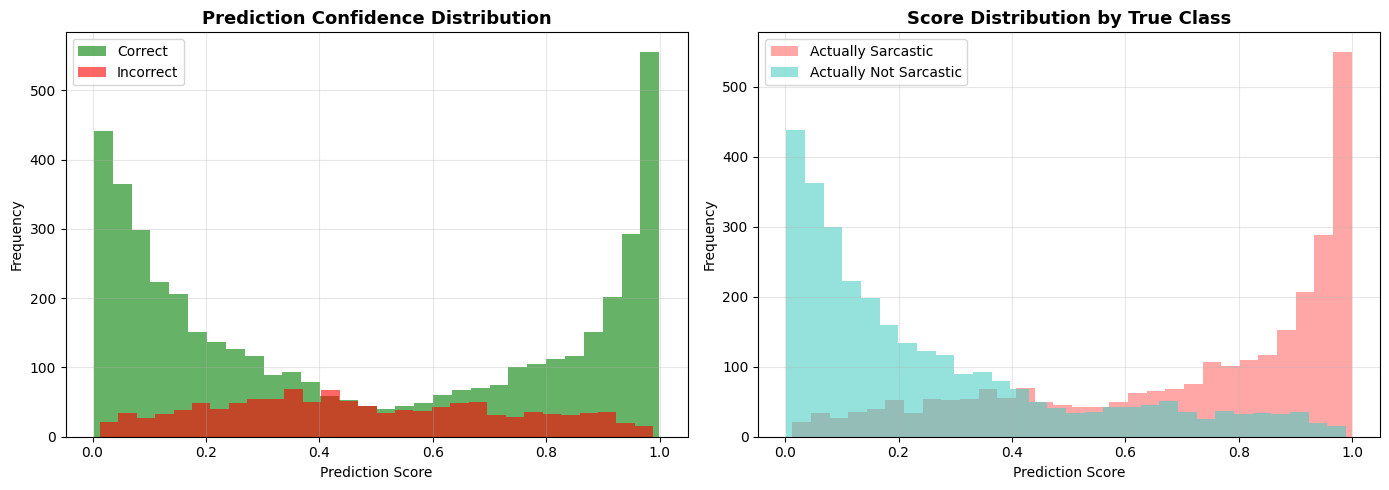

In [ ]:
# Confidence distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

correct_conf = y_pred_prob_ea[~misclassified_mask]
incorrect_conf = y_pred_prob_ea[misclassified_mask]

ax1.hist(correct_conf, bins=30, alpha=0.6, color='green', label='Correct')
ax1.hist(incorrect_conf, bins=30, alpha=0.6, color='red', label='Incorrect')
ax1.set_title('Prediction Confidence Distribution', fontsize=13, fontweight='bold')
ax1.set_xlabel('Prediction Score')
ax1.set_ylabel('Frequency')
ax1.legend()
ax1.grid(True, alpha=0.3)

sarc_scores = y_pred_prob_ea[y_test == 1]
non_sarc_scores = y_pred_prob_ea[y_test == 0]

ax2.hist(sarc_scores, bins=30, alpha=0.6, color='#FF6B6B', label='Actually Sarcastic')
ax2.hist(non_sarc_scores, bins=30, alpha=0.6, color='#4ECDC4', label='Actually Not Sarcastic')
ax2.set_title('Score Distribution by True Class', fontsize=13, fontweight='bold')
ax2.set_xlabel('Prediction Score')
ax2.set_ylabel('Frequency')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
save_plot('confidence_distribution')
plt.show()

---
## 8. GUI for Real-Time Prediction

In [ ]:
# GUI using Gradio
import gradio as gr

def predict_sarcasm(headline):
    cleaned = clean_text(headline)
    seq = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=MAX_LENGTH, padding='post', truncating='post')

    results_text = ""
    for name, model in [('Simple RNN', model_rnn), ('LSTM', model_lstm), ('LSTM + Word2Vec', model_w2v)]:
        pred = model.predict(padded, verbose=0)[0][0]
        label = "SARCASTIC" if pred > 0.5 else "NOT SARCASTIC"
        confidence = pred if pred > 0.5 else 1 - pred
        results_text += f"{name}: {label} (Confidence: {confidence:.1%})\n"
    return results_text

interface = gr.Interface(
    fn=predict_sarcasm,
    inputs=gr.Textbox(placeholder="Enter a headline...", label="News Headline", lines=2),
    outputs=gr.Textbox(label="Prediction Results"),
    title="Sarcasm Detection in News Headlines",
    description="Enter a news headline to predict sarcasm. Uses RNN, LSTM, and LSTM+Word2Vec models.",
    examples=[
        ["area man passionate defender of what he imagines constitution to be"],
        ["new study finds connection between diet and health"],
        ["nation celebrates full week without mass shooting"],
        ["scientists discover high correlation between eating food and not being hungry"],
    ]
)
interface.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://bb623ffb440302a844.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
